In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000  # top 10k words
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding sequences
max_len = 200

x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

embedding_dim = 128

In [4]:
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [6]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
epochs = 5
batch_size = 64

history_rnn = model_rnn.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)
history_lstm = model_lstm.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)
history_gru = model_gru.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.5256 - loss: 0.6870 - val_accuracy: 0.5342 - val_loss: 0.6807
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.6343 - loss: 0.6052 - val_accuracy: 0.5696 - val_loss: 0.6778
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.7046 - loss: 0.4869 - val_accuracy: 0.5252 - val_loss: 0.8353
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.7327 - loss: 0.4125 - val_accuracy: 0.5390 - val_loss: 0.8917
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.7557 - loss: 0.3721 - val_accuracy: 0.5372 - val_loss: 0.9534
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 271ms/step - accuracy: 0.5957 - loss: 0.6491 - val_accuracy: 0.6078 - val_loss: 0.6337
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 276ms/step - accuracy: 0.6943 - loss: 0.5744 - val_accuracy: 0.7960 - val_loss: 0.4677
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.7261 - loss: 0.5474 - val

In [8]:
rnn_acc = model_rnn.evaluate(x_test, y_test)
lstm_acc = model_lstm.evaluate(x_test, y_test)
gru_acc = model_gru.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5393 - loss: 0.9400
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.8240 - loss: 0.4198
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8683 - loss: 0.3533


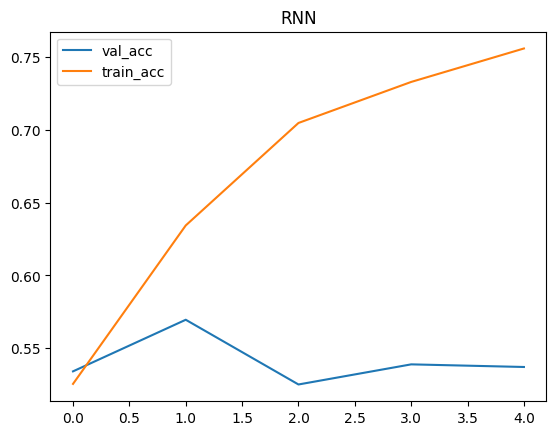

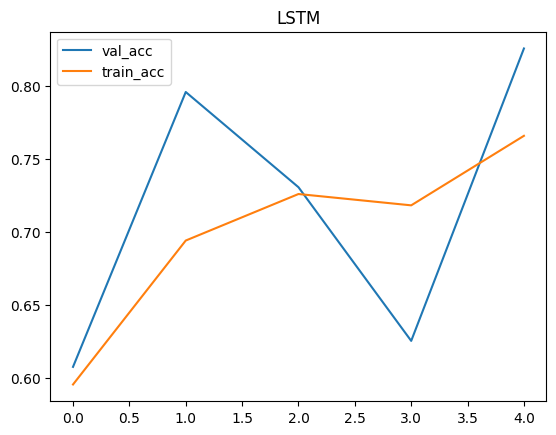

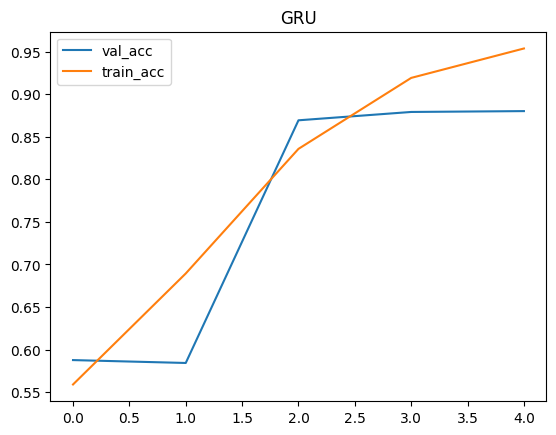

In [10]:
import matplotlib.pyplot as plt

def plot(history, title):
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.title(title)
    plt.legend()
    plt.show()

plot(history_rnn, "RNN")
plot(history_lstm, "LSTM")
plot(history_gru, "GRU")

In [29]:

from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load word index
word_index = imdb.get_word_index()

def encode_text(text):
    words = text.lower().split()
    seq = []
    for word in words:
        if word in word_index:
            seq.append(word_index[word] + 3)  # offset in IMDB
        else:
            seq.append(2)  # unknown token
    return seq

sentences = [
    "This movie was amazing",
    "The movie was boring"
]

encoded = [encode_text(s) for s in sentences]
padded = pad_sequences(encoded, maxlen=200)

pred = model_lstm.predict(padded)

for i, s in enumerate(sentences):
    print(s, "->", "Positive" if pred[i] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
This movie was amazing -> Positive
The movie was boring -> Negative
